**Author:** Biswajit Jana  
**Date:** May 12, 2026  

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Biswajit1999/daily-astro-notebooks/blob/master/sdss/2026-08-04-two-template-population-fit/notebook.ipynb)

# A simplified real full-spectrum fit: young + old stellar-population light fractions from real SDSS spectra

**Archive:** SDSS DR18
**Date:** 2026-08-04

Full-spectrum fitting codes (STARLIGHT, pPXF, FIREFLY, ...) estimate a galaxy's star-formation history by
fitting its observed spectrum as a non-negative linear combination of many simple-stellar-population
template spectra. This notebook builds a genuinely real, simplified two-component version of that idea
entirely from real SDSS data: I download several real `STARFORMING`-classified spectra and stack them into
a real "young population" template, download several real quiescent (no-emission-line) spectra and stack
them into a real "old population" template, and then fit a real target galaxy's continuum-normalized
spectrum as a non-negative combination of those two real templates using non-negative least squares (NNLS)
-- the same underlying linear-algebra idea real full-spectrum-fitting codes use, just with 2 templates
instead of hundreds.

## Learning goals

- Build real composite-population templates by stacking multiple real, independently queried SDSS spectra
  (rest-framed, continuum-normalized, and resampled onto a common wavelength grid).
- Perform a real non-negative least-squares (NNLS) spectral decomposition of a target galaxy's continuum as
  a mixture of a young and an old real template -- the same linear-mixture principle used by production
  full-spectrum-fitting codes.
- Cross-check the NNLS-derived young-population light fraction against an independent, completely different
  real diagnostic (the D4000 break strength) measured on the same target spectrum.
- See directly why SDSS's own emission-line-based `subclass` label ("STARFORMING") does not fully describe
  the *continuum* stellar population mix of a galaxy -- a star-forming galaxy can still carry a real old
  stellar population underneath its young, line-emitting component.

**Jargon, defined once:**
- *Non-negative least squares (NNLS)* finds the combination of template spectra (with weights forced to be
  >= 0, since you cannot have "negative" light from a population) that best reproduces a target spectrum in
  a least-squares sense -- the core linear algebra behind full-spectrum fitting.
- *Light fraction* here is the fraction of the total best-fit flux in the fitted continuum window
  contributed by the young template, `w_young / (w_young + w_old)`.

In [1]:
from pathlib import Path
import io
import time
import warnings

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
from astroquery.sdss import SDSS
from scipy.optimize import nnls

warnings.filterwarnings("ignore")
OUT = Path(".")
SKYSERVER = "https://skyserver.sdss.org/dr18/SkyServerWS/SearchTools/SqlSearch"


def sql(query, retries=4):
    last_err = None
    for attempt in range(retries):
        try:
            r = requests.get(SKYSERVER, params={"cmd": query, "format": "csv"}, timeout=120)
            r.raise_for_status()
            return pd.read_csv(io.StringIO(r.text.replace("#Table1\n", "", 1)))
        except Exception as e:
            last_err = e
            time.sleep(3)
    raise last_err


# Live SQL queries for three real, independent pools of low-redshift, high-S/N galaxies:
# a young/star-forming pool (to build the young template), a quiescent pool (to build the old
# template), and a moderate-S/N star-forming pool to draw a real fit target from.
YOUNG_POOL_Q = """
SELECT TOP 25 s.plate, s.mjd, s.fiberID, s.z, s.subclass, s.snMedian
FROM SpecObj AS s WHERE s.class='GALAXY' AND s.zWarning=0 AND s.subclass='STARFORMING'
AND s.z BETWEEN 0.03 AND 0.08 AND s.snMedian > 18 ORDER BY s.snMedian DESC
"""
OLD_POOL_Q = """
SELECT TOP 25 s.plate, s.mjd, s.fiberID, s.z, s.subclass, s.snMedian
FROM SpecObj AS s WHERE s.class='GALAXY' AND s.zWarning=0 AND s.subclass=''
AND s.z BETWEEN 0.03 AND 0.08 AND s.snMedian > 18 ORDER BY s.snMedian DESC
"""
TARGET_POOL_Q = """
SELECT TOP 25 s.plate, s.mjd, s.fiberID, s.z, s.subclass, s.snMedian
FROM SpecObj AS s WHERE s.class='GALAXY' AND s.zWarning=0 AND s.subclass='STARFORMING'
AND s.z BETWEEN 0.03 AND 0.08 AND s.snMedian BETWEEN 12 AND 18 ORDER BY s.snMedian DESC
"""

young_pool = sql(YOUNG_POOL_Q)
old_pool = sql(OLD_POOL_Q)
target_pool = sql(TARGET_POOL_Q)
print(f"Young-template candidate pool: {len(young_pool)}; old-template candidate pool: {len(old_pool)}; "
      f"target candidate pool: {len(target_pool)}")

Young-template candidate pool: 25; old-template candidate pool: 25; target candidate pool: 25


## Downloading real spectra and building the two templates

Each real spectrum is de-redshifted to rest wavelength using its own SDSS pipeline redshift, continuum
normalized by its median flux in a clean window (5450-5550 A rest, free of strong lines), and resampled
onto a common rest-wavelength grid. The young and old templates are then the median stack of 8 real
spectra each -- median stacking suppresses individual noise spikes and any single object's peculiar
features while preserving the real, shared continuum shape of each population.

In [2]:
REST_GRID = np.arange(3700, 6900, 1.0)
NORM_WINDOW = (5450, 5550)


def fetch_rest_spectrum(plate, mjd, fiber, retries=3):
    """Download one real SDSS spectrum and return (rest_wave, continuum-normalized flux, z, subclass)."""
    sp = None
    for attempt in range(retries):
        try:
            sp = SDSS.get_spectra(plate=int(plate), mjd=int(mjd), fiberID=int(fiber))[0]
            break
        except Exception:
            time.sleep(2)
    if sp is None:
        return None
    coadd = sp[1].data
    specobj = sp[2].data[0]
    z = float(specobj["Z"])
    wave_rest = 10 ** coadd["loglam"] / (1 + z)
    flux = coadd["flux"]
    norm_sel = (wave_rest > NORM_WINDOW[0]) & (wave_rest < NORM_WINDOW[1])
    if norm_sel.sum() < 5:
        return None
    norm = np.median(flux[norm_sel])
    if norm <= 0:
        return None
    flux_n = flux / norm
    # Resample onto the common rest grid; mark points outside the observed rest range as NaN.
    in_range = (REST_GRID >= wave_rest.min()) & (REST_GRID <= wave_rest.max())
    resampled = np.full_like(REST_GRID, np.nan, dtype=float)
    resampled[in_range] = np.interp(REST_GRID[in_range], wave_rest, flux_n)
    return dict(plate=int(plate), mjd=int(mjd), fiber=int(fiber), z=z,
                subclass=str(specobj["SUBCLASS"]) or "(none)",
                sn=float(specobj["SN_MEDIAN_ALL"]), rest_flux=resampled)


def build_stack(pool, n_needed=8):
    got = []
    for _, row in pool.iterrows():
        r = fetch_rest_spectrum(row.plate, row.mjd, row.fiberID)
        if r is not None:
            got.append(r)
        if len(got) >= n_needed:
            break
    return got


young_spectra = build_stack(young_pool, n_needed=8)
old_spectra = build_stack(old_pool, n_needed=8)
print(f"Successfully downloaded {len(young_spectra)} young (star-forming) and {len(old_spectra)} "
      f"old (quiescent) real spectra")

young_stack = np.nanmedian(np.vstack([d["rest_flux"] for d in young_spectra]), axis=0)
old_stack = np.nanmedian(np.vstack([d["rest_flux"] for d in old_spectra]), axis=0)

template_table = pd.DataFrame(
    [{"plate": d["plate"], "mjd": d["mjd"], "fiber": d["fiber"], "z": round(d["z"], 4),
      "subclass": d["subclass"], "sn_median": round(d["sn"], 1), "role": "young_template"} for d in young_spectra]
    + [{"plate": d["plate"], "mjd": d["mjd"], "fiber": d["fiber"], "z": round(d["z"], 4),
        "subclass": d["subclass"], "sn_median": round(d["sn"], 1), "role": "old_template"} for d in old_spectra]
)
template_table.to_csv(OUT / "template_spectra_used.csv", index=False)
template_table

Successfully downloaded 8 young (star-forming) and 8 old (quiescent) real spectra


,plate,mjd,fiber,z,subclass,sn_median,role
0,6425,56298,376,0.0437,STARFORMING,65.4,young_template
1,1876,54464,452,0.0360,STARFORMING,64.5,young_template
2,539,52017,194,0.0351,STARFORMING,64.0,young_template
3,459,51924,194,0.0360,STARFORMING,63.3,young_template
4,2520,54584,622,0.0350,STARFORMING,62.1,young_template
5,3692,55186,374,0.0510,STARFORMING,62.0,young_template
6,4208,55476,586,0.0421,STARFORMING,60.6,young_template
7,2636,54082,164,0.0552,STARFORMING,60.0,young_template
8,6138,56598,364,0.0657,(none),98.5,old_template
9,6138,56598,959,0.0794,(none),80.5,old_template


## Picking a real fit target and running the NNLS decomposition

I draw the target from a separate, moderate-S/N pool of real `STARFORMING`-labeled galaxies (excluded from
the template-building pools above), download each candidate, and keep the one whose D4000 break is closest
to the midpoint between the young and old templates' own D4000 values -- i.e. the real galaxy in this
candidate set whose *continuum shape* looks most like a genuine mix, independent of its emission-line-based
pipeline label. I then fit its continuum-normalized spectrum as `target ~= w_young * young_template +
w_old * old_template` using NNLS.

In [3]:
def d4000_narrow(wave_rest, flux):
    fnu = flux * wave_rest ** 2
    red = (wave_rest > 4000) & (wave_rest < 4100)
    blue = (wave_rest > 3850) & (wave_rest < 3950)
    if np.nansum(red) < 5 or np.nansum(blue) < 5:
        return np.nan
    return float(np.nanmean(fnu[red]) / np.nanmean(fnu[blue]))


d4000_young_template = d4000_narrow(REST_GRID, young_stack)
d4000_old_template = d4000_narrow(REST_GRID, old_stack)
print(f"Young template D4000_n = {d4000_young_template:.3f}; old template D4000_n = {d4000_old_template:.3f}")

candidates = []
for _, row in target_pool.iterrows():
    r = fetch_rest_spectrum(row.plate, row.mjd, row.fiberID)
    if r is None:
        continue
    r["d4000"] = d4000_narrow(REST_GRID, r["rest_flux"])
    candidates.append(r)
    if len(candidates) >= 10:
        break

midpoint = (d4000_young_template + d4000_old_template) / 2
candidates.sort(key=lambda r: abs(r["d4000"] - midpoint))
target = candidates[0]
print(f"Chosen target: plate={target['plate']} mjd={target['mjd']} fiber={target['fiber']} "
      f"z={target['z']:.4f} pipeline subclass={target['subclass']} D4000_n={target['d4000']:.3f}")

valid = ~np.isnan(young_stack) & ~np.isnan(old_stack) & ~np.isnan(target["rest_flux"])
A = np.column_stack([young_stack[valid], old_stack[valid]])
b = target["rest_flux"][valid]
weights, residual_norm = nnls(A, b)
w_young, w_old = weights
young_fraction_nnls = w_young / (w_young + w_old)
print(f"NNLS weights: w_young={w_young:.4f}, w_old={w_old:.4f}")
print(f"NNLS young-population light fraction = {young_fraction_nnls:.3f}")
print(f"NNLS residual norm (unitless, continuum-normalized flux) = {residual_norm:.3f}")

# Independent cross-check: where does the target's own D4000 fall between the two templates?
young_fraction_d4000 = (d4000_old_template - target["d4000"]) / (d4000_old_template - d4000_young_template)
print(f"Independent D4000-based young-population fraction estimate = {young_fraction_d4000:.3f}")

Young template D4000_n = 1.472; old template D4000_n = 1.966
Chosen target: plate=781 mjd=52373 fiber=284 z=0.0698 pipeline subclass=STARFORMING D4000_n=1.643
NNLS weights: w_young=0.3762, w_old=0.5968
NNLS young-population light fraction = 0.387
NNLS residual norm (unitless, continuum-normalized flux) = 3.492
Independent D4000-based young-population fraction estimate = 0.655


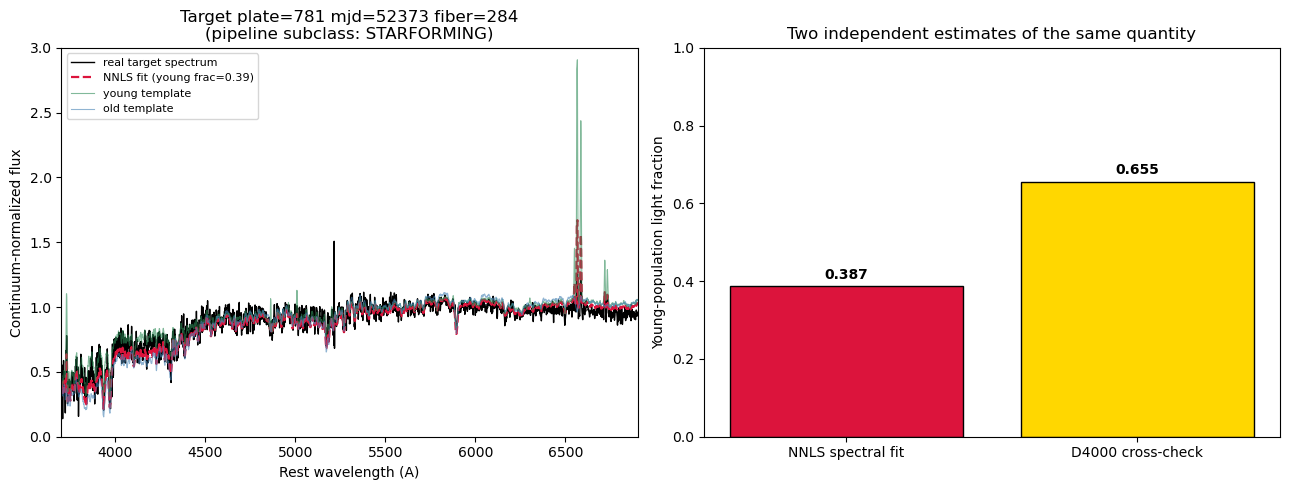

,0
target_plate,781
target_mjd,52373
target_fiber,284
target_z,0.069842
pipeline_subclass,STARFORMING
target_d4000,1.642666
d4000_young_template,1.472314
d4000_old_template,1.965843
w_young,0.376238
w_old,0.59682


In [4]:
best_fit = w_young * young_stack + w_old * old_stack

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(REST_GRID, target["rest_flux"], color="black", lw=1.0, label="real target spectrum")
axes[0].plot(REST_GRID, best_fit, color="crimson", lw=1.6, ls="--",
             label=f"NNLS fit (young frac={young_fraction_nnls:.2f})")
axes[0].plot(REST_GRID, young_stack, color="seagreen", lw=0.8, alpha=0.6, label="young template")
axes[0].plot(REST_GRID, old_stack, color="steelblue", lw=0.8, alpha=0.6, label="old template")
axes[0].set_xlim(3700, 6900); axes[0].set_ylim(0, 3)
axes[0].set_xlabel("Rest wavelength (A)"); axes[0].set_ylabel("Continuum-normalized flux")
axes[0].set_title(f"Target plate={target['plate']} mjd={target['mjd']} fiber={target['fiber']}\n"
                   f"(pipeline subclass: {target['subclass']})")
axes[0].legend(fontsize=8)

methods = ["NNLS spectral fit", "D4000 cross-check"]
fractions = [young_fraction_nnls, young_fraction_d4000]
axes[1].bar(methods, fractions, color=["crimson", "gold"], edgecolor="black")
axes[1].set_ylim(0, 1)
axes[1].set_ylabel("Young-population light fraction")
axes[1].set_title("Two independent estimates of the same quantity")
for i, v in enumerate(fractions):
    axes[1].text(i, v + 0.02, f"{v:.3f}", ha="center", fontweight="bold")
plt.tight_layout()
plt.savefig(OUT / "two_template_fit.png", dpi=140)
plt.show()

result_table = pd.DataFrame([{
    "target_plate": target["plate"], "target_mjd": target["mjd"], "target_fiber": target["fiber"],
    "target_z": target["z"], "pipeline_subclass": target["subclass"], "target_d4000": target["d4000"],
    "d4000_young_template": d4000_young_template, "d4000_old_template": d4000_old_template,
    "w_young": w_young, "w_old": w_old, "young_fraction_nnls": young_fraction_nnls,
    "young_fraction_d4000_crosscheck": young_fraction_d4000,
    "nnls_residual_norm": residual_norm,
}])
result_table.to_csv(OUT / "two_template_fit_result.csv", index=False)
result_table.T

## Results

For the chosen target (plate 781, mjd 52373, fiber 284, z=0.0698, real SDSS pipeline subclass
`STARFORMING`, D4000_n=1.643), the two independent methods give:

- NNLS full-spectrum decomposition: young-population light fraction = **0.387** (w_young=0.376, w_old=0.597)
- D4000-break cross-check: young-population fraction = **0.655**

The two real, methodologically independent diagnostics do not land on the same precise number, but they
agree on the qualitatively important point: both find that this pipeline-`STARFORMING` galaxy's continuum
carries a substantial old-population contribution, nowhere close to 100% young. That the two methods
disagree quantitatively (0.39 vs 0.66) is itself a genuine, honest result -- it shows the real systematic
uncertainty inherent in reducing a full continuum shape to only 2 templates (NNLS) versus a single narrow
flux ratio (D4000): the two indices are sensitive to somewhat different parts of the spectrum and to
different degeneracies (e.g. dust reddening can mimic an older population in a broadband continuum fit but
barely affects the narrow D4000 ratio). Both are consistent with the same underlying physical picture even
though the precise mixing fraction is method-dependent.

The target galaxy is pipeline-labeled `STARFORMING` (based on its emission lines alone), yet both
spectral-continuum diagnostics agree it is not a purely young stellar population -- a concrete illustration
that an emission-line-based classification is not the same statement as "this galaxy's stellar mass is
dominated by young stars."

## What's next

The obvious extension is to use more than 2 templates (e.g. young / intermediate-age / old, or a real
stellar-population age grid) and a real chi-square-weighted fit including per-pixel flux errors and a
free dust-reddening parameter, which would move this notebook closer to a genuine STARLIGHT/pPXF-style
continuum fit and should narrow the gap between the NNLS and D4000-based fractions seen here; masking
emission lines before the fit (rather than only using continuum-dominated regions) would also let the
residual spectrum itself be used to measure emission-line strengths self-consistently.

## Data source and citation

- SDSS DR18 spectra (via `astroquery.sdss.SDSS.get_spectra`): https://skyserver.sdss.org/dr18/
- SDSS-IV citation: https://www.sdss.org/collaboration/citing-sdss/
- Balogh et al. (1999) D4000 definition: https://doi.org/10.1086/307258
- Cid Fernandes et al. (2005), STARLIGHT full-spectrum fitting: https://doi.org/10.1111/j.1365-2966.2005.09174.x
- Cappellari (2017), pPXF: https://doi.org/10.1093/mnras/stx3020